# Portfolio Training with Walk-Forward Validation

Train PPO agent for portfolio rebalancing using walk-forward validation.

**Configuration:** All parameters defined in `config.py`

**Key Features:**
- Walk-forward validation (no data leakage)
- Configurable reward functions
- 7 tech stocks, weekly rebalancing
- 149 features (macro + technical + volume + risk)

## Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import config and RL system
from config import *
from rl_system import (
    PortfolioEnv,
    PortfolioMonitor,
    TrainingLogger,
    create_walk_forward_folds,
    print_fold_summary
)

print("✓ Imports complete")

✓ Imports complete


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Configuration

In [2]:
# Print current configuration
print_config()

CONFIGURATION

📊 DATA
   Data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed/train.parquet
   Tickers: 7 - NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
   Features: 149
   Metadata: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed/metadata.json

🎯 ENVIRONMENT
   Reward: multi_component (lookback=12)
   Rebalance: 4 weeks
   Transaction cost: 0.0025 (25 bps)
   Max weight: 40%

🔄 VALIDATION
   Folds: 3

🤖 TRAINING
   Timesteps: 50,000
   Learning rate: 0.0003
   Batch size: 64
   Network: [256, 256]


## Load Data

In [4]:
# Load training data using config
train_data = load_data()

print(f"\n✓ Loaded {len(train_data):,} samples")
print(f"  Date range: {train_data[DATE_COL].min().date()} to {train_data[DATE_COL].max().date()}")
print(f"  Tickers: {train_data['ticker'].nunique()}")
print(f"  Features: {len(FEATURE_COLS)}")


✓ Loaded 1,708 samples
  Date range: 2020-01-01 to 2024-08-28
  Tickers: 7
  Features: 149


## Create Walk-Forward Folds

In [5]:
# Create folds using config parameters
folds = create_walk_forward_folds(
    train_data=train_data,
    n_folds=N_FOLDS,
    min_train_size=MIN_TRAIN_SIZE,
    date_col=DATE_COL
)

print_fold_summary(folds)

WALKING FORWARD VALIDATION FOLDS

Fold 0:
  Train: 2020-01-01 to 2020-12-23 (52 periods)
  Val:   2020-12-30 to 2022-03-16 (64 periods)
  Train samples: 364
  Val samples:   448

Fold 1:
  Train: 2020-01-01 to 2022-03-16 (116 periods)
  Val:   2022-03-23 to 2023-06-07 (64 periods)
  Train samples: 812
  Val samples:   448

Fold 2:
  Train: 2020-01-01 to 2023-06-07 (180 periods)
  Val:   2023-06-14 to 2024-08-28 (64 periods)
  Train samples: 1260
  Val samples:   448



## Training Function

In [ ]:
def train_fold(fold_idx, train_data, val_data):
    """
    Train PPO agent on one fold.
    All parameters from config.py.
    """
    print(f"\n{'='*80}")
    print(f"FOLD {fold_idx + 1}/{N_FOLDS}")
    print(f"{'='*80}")
    
    # Verify data
    print(f"\n📊 Data:")
    print(f"   Train: {train_data[DATE_COL].min().date()} to {train_data[DATE_COL].max().date()} ({len(train_data['date'].unique())} periods)")
    print(f"   Val:   {val_data[DATE_COL].min().date()} to {val_data[DATE_COL].max().date()} ({len(val_data['date'].unique())} periods)")
    
    assert train_data[DATE_COL].max() < val_data[DATE_COL].min(), "Data leakage!"
    print(f"   ✓ No data leakage")
    
    # Create environments
    def make_env(data):
        env = PortfolioEnv(
            data=data.copy(),
            feature_cols=FEATURE_COLS,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            max_weight_per_asset=MAX_WEIGHT_PER_ASSET,
            reward_lookback=REWARD_LOOKBACK,
            initial_capital=INITIAL_CAPITAL,
            reward_type=REWARD_TYPE,
            seed=RANDOM_SEED + fold_idx
        )
        return PortfolioMonitor(env)
    
    train_env = DummyVecEnv([lambda: make_env(train_data)])
    val_env = DummyVecEnv([lambda: make_env(val_data)])
    
    # Setup output directory
    fold_dir = Path(OUTPUT_DIR) / f"fold_{fold_idx}"
    fold_dir.mkdir(parents=True, exist_ok=True)
    
    # Create callback
    logger = TrainingLogger(
        eval_env=val_env,
        eval_freq=EVAL_FREQ,
        fold_dir=fold_dir,
        patience=10,
        verbose=VERBOSE
    )
    
    # Create model
    model = PPO(
        "MlpPolicy",
        train_env,
        policy_kwargs=POLICY_KWARGS,
        learning_rate=LEARNING_RATE,
        n_steps=N_STEPS,
        batch_size=BATCH_SIZE,
        n_epochs=N_EPOCHS,
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA,
        clip_range=CLIP_RANGE,
        ent_coef=ENT_COEF,
        vf_coef=VF_COEF,
        max_grad_norm=MAX_GRAD_NORM,
        verbose=0,
        tensorboard_log=str(fold_dir / "tensorboard") if USE_TENSORBOARD else None
    )
    
    # Train
    print_training_params()
    print(f"\n🤖 Training for {TOTAL_TIMESTEPS:,} timesteps...\n")
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=logger,
        progress_bar=False
    )
    
    # Save model
    if SAVE_ALL_MODELS:
        model.save(str(fold_dir / "final_model"))
    
    # Final validation
    print(f"\n📈 Final Validation:")
    obs = val_env.reset()
    done = False
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = val_env.step(action)
        
        if done[0]:
            stats = info[0].get('portfolio_stats', {})
    
    # Print results
    print(f"   Total Return:  {stats['total_return']*100:>7.2f}%")
    print(f"   Sharpe Ratio:  {stats['sharpe_ratio']:>7.3f}")
    print(f"   Volatility:    {stats['volatility']*100:>7.2f}%")
    print(f"   Max Drawdown:  {stats['max_drawdown']*100:>7.2f}%")
    print(f"   Final Value:   ${stats['portfolio_value']:>,.2f}")
    print(f"   Best Val Sharpe: {logger.best_val_sharpe:>7.3f}")
    
    # Return results
    return {
        'fold': fold_idx,
        'total_return': stats['total_return'],
        'sharpe_ratio': stats['sharpe_ratio'],
        'volatility': stats['volatility'],
        'max_drawdown': stats['max_drawdown'],
        'portfolio_value': stats['portfolio_value'],
        'best_val_sharpe': logger.best_val_sharpe,
        'early_stopped': logger.early_stopped,
        'model_path': str(fold_dir / "best_model")
    }

print("✓ Training function defined")

✓ Training function defined


## Train All Folds

In [7]:
# Train all folds
# Override config parameters if needed (optional):
REWARD_TYPE = 'risk_aware'
TOTAL_TIMESTEPS = 100000  # Override timesteps from config

results = []

for fold in folds:
    result = train_fold(
        fold_idx=fold['fold_idx'],
        train_data=fold['train'],
        val_data=fold['val']
    )
    results.append(result)

print(f"\n{'='*80}")
print("✓ ALL FOLDS COMPLETE")
print(f"{'='*80}")


FOLD 1/3

📊 Data:
   Train: 2020-01-01 to 2020-12-23 (52 periods)
   Val:   2020-12-30 to 2022-03-16 (64 periods)
   ✓ No data leakage

🤖 Training for 100,000 timesteps...

  Train Episode 20: Sharpe=1.996, Return=107.58%
  Train Episode 40: Sharpe=1.037, Return=47.54%

  Validation at step 2500:
    Sharpe: 0.362
    Return: 14.04%
    Portfolio value: $114,036.32
  ✓ New best! (Sharpe: 0.362)
  Train Episode 60: Sharpe=0.936, Return=39.46%
  Train Episode 80: Sharpe=2.011, Return=83.98%

  Validation at step 5000:
    Sharpe: 0.973
    Return: 40.46%
    Portfolio value: $140,463.77
  ✓ New best! (Sharpe: 0.973)
  Train Episode 100: Sharpe=1.132, Return=50.64%
  Train Episode 120: Sharpe=1.245, Return=51.54%
  Train Episode 140: Sharpe=0.975, Return=40.71%

  Validation at step 7500:
    Sharpe: 0.790
    Return: 29.16%
    Portfolio value: $129,163.26
  No improvement (1/10)
  Train Episode 160: Sharpe=1.604, Return=68.43%
  Train Episode 180: Sharpe=1.998, Return=65.12%

  Validat

## Results Summary

In [8]:
# Create results DataFrame
results_df = pd.DataFrame(results)

# Save results
output_path = Path(OUTPUT_DIR) / 'fold_results.csv'
results_df.to_csv(output_path, index=False)

# Print summary
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

print(f"\n📊 Validation Performance:")
print(f"   Sharpe Ratio:  {results_df['sharpe_ratio'].mean():.3f} ± {results_df['sharpe_ratio'].std():.3f}")
print(f"   Total Return:  {results_df['total_return'].mean():.2%} ± {results_df['total_return'].std():.2%}")
print(f"   Volatility:    {results_df['volatility'].mean():.2%} ± {results_df['volatility'].std():.2%}")
print(f"   Max Drawdown:  {results_df['max_drawdown'].mean():.2%} ± {results_df['max_drawdown'].std():.2%}")
print(f"   Best Sharpe:   {results_df['best_val_sharpe'].mean():.3f} ± {results_df['best_val_sharpe'].std():.3f}")

print(f"\n💾 Saved to: {output_path}")

# Display table
results_df


RESULTS SUMMARY

📊 Validation Performance:
   Sharpe Ratio:  0.500 ± 0.331
   Total Return:  20.41% ± 11.49%
   Volatility:    33.50% ± 8.16%
   Max Drawdown:  -31.06% ± 8.99%
   Best Sharpe:   0.718 ± 0.497

💾 Saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/fold_results.csv


,fold,total_return,sharpe_ratio,volatility,max_drawdown,portfolio_value,best_val_sharpe,early_stopped,model_path
0,0,0.302016,0.798108,0.270763,-0.242796,130201.583041,0.973106,True,/Users/nataliamarko/Documents/GitHub_Projects/...
1,1,0.077583,0.143330,0.426869,-0.412566,107758.345643,0.145875,True,/Users/nataliamarko/Documents/GitHub_Projects/...
2,2,0.232623,0.557191,0.307348,-0.276302,123262.320298,1.036263,True,/Users/nataliamarko/Documents/GitHub_Projects/...


## Visualize Results

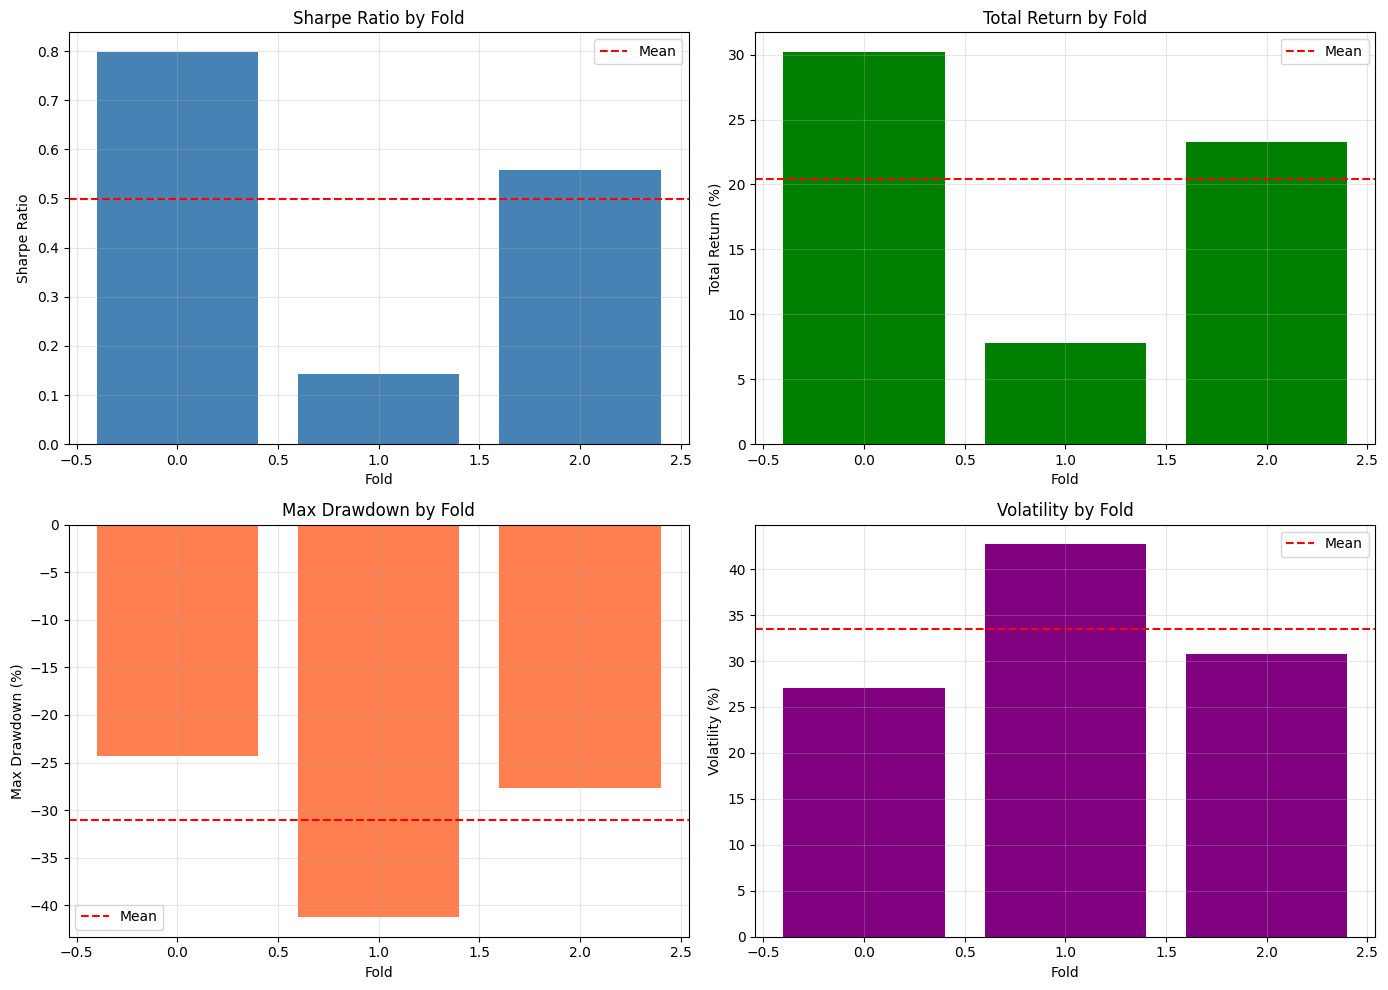


💾 Plot saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/fold_results.png


In [9]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sharpe Ratio
axes[0, 0].bar(results_df['fold'], results_df['sharpe_ratio'], color='steelblue')
axes[0, 0].axhline(results_df['sharpe_ratio'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('Sharpe Ratio')
axes[0, 0].set_title('Sharpe Ratio by Fold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Total Return
axes[0, 1].bar(results_df['fold'], results_df['total_return']*100, color='green')
axes[0, 1].axhline(results_df['total_return'].mean()*100, color='red', linestyle='--', label='Mean')
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('Total Return (%)')
axes[0, 1].set_title('Total Return by Fold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Max Drawdown
axes[1, 0].bar(results_df['fold'], results_df['max_drawdown']*100, color='coral')
axes[1, 0].axhline(results_df['max_drawdown'].mean()*100, color='red', linestyle='--', label='Mean')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('Max Drawdown (%)')
axes[1, 0].set_title('Max Drawdown by Fold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Volatility
axes[1, 1].bar(results_df['fold'], results_df['volatility']*100, color='purple')
axes[1, 1].axhline(results_df['volatility'].mean()*100, color='red', linestyle='--', label='Mean')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('Volatility (%)')
axes[1, 1].set_title('Volatility by Fold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

# Save plot
plot_path = Path(OUTPUT_DIR) / 'fold_results.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💾 Plot saved to: {plot_path}")

In [10]:
# Train all folds
# Override config parameters if needed (optional):
REWARD_TYPE = 'multi_component'
TOTAL_TIMESTEPS = 100000  # Override timesteps from config

results = []

for fold in folds:
    result = train_fold(
        fold_idx=fold['fold_idx'],
        train_data=fold['train'],
        val_data=fold['val']
    )
    results.append(result)

print(f"\n{'='*80}")
print("✓ ALL FOLDS COMPLETE")
print(f"{'='*80}")


FOLD 1/3

📊 Data:
   Train: 2020-01-01 to 2020-12-23 (52 periods)
   Val:   2020-12-30 to 2022-03-16 (64 periods)
   ✓ No data leakage

🤖 Training for 100,000 timesteps...

  Train Episode 20: Sharpe=1.148, Return=50.38%
  Train Episode 40: Sharpe=0.866, Return=36.17%

  Validation at step 2500:
    Sharpe: 0.437
    Return: 15.44%
    Portfolio value: $115,444.94
  ✓ New best! (Sharpe: 0.437)
  Train Episode 60: Sharpe=0.837, Return=32.20%
  Train Episode 80: Sharpe=1.509, Return=59.57%

  Validation at step 5000:
    Sharpe: 0.539
    Return: 21.23%
    Portfolio value: $121,230.90
  ✓ New best! (Sharpe: 0.539)
  Train Episode 100: Sharpe=1.803, Return=87.23%
  Train Episode 120: Sharpe=1.788, Return=80.32%
  Train Episode 140: Sharpe=1.639, Return=57.68%

  Validation at step 7500:
    Sharpe: 0.610
    Return: 24.70%
    Portfolio value: $124,702.59
  ✓ New best! (Sharpe: 0.610)
  Train Episode 160: Sharpe=1.262, Return=49.99%
  Train Episode 180: Sharpe=1.538, Return=61.27%

  Va

## Notes

- All parameters defined in `config.py`
- Test data kept separate for final evaluation
- Models saved to `models/` directory
- Best model per fold saved with `TrainingLogger`